# Setting Directories

# Imports

In [18]:
import subprocess
import shutil
from pathlib import Path

from Scripts.prep_docking import run_workflow


# Config

In [19]:

wd = Path.home() / "master_dev"
wdlogs = wd / "logs"

orai_folder = wd / "Orai"

# Pocket detection is protein-only — no ligand dependency
base_results_folder = wd / "pocket_results"
base_results_folder.mkdir(parents=True, exist_ok=True)

p2rank_results_folder = base_results_folder / "p2rank_results"
p2rank_results_folder.mkdir(exist_ok=True)

fpocket_results_folder = base_results_folder / "fpocket_results"
fpocket_results_folder.mkdir(exist_ok=True)

# Get all PDB files in orai_folder
pdb_files = list(orai_folder.glob("*.pdb"))
print(f"Found {len(pdb_files)} PDB files")


Found 4 PDB files


In [20]:
P2RANK_DIR = str(Path.home() / "tools" / "p2rank_2.5")
P2RANK_PATH = str(Path(P2RANK_DIR) / "prank")

print(f"\n{'='*60}")
print(f"p2rank — predicting pockets for {len(pdb_files)} proteins")
print(f"{'='*60}")

for pdb_file in pdb_files:
    print(f"  Processing {pdb_file.name} with p2rank...")
    result = subprocess.run(
        [P2RANK_PATH, "predict", "-f", str(pdb_file), "-o", str(p2rank_results_folder)],
        capture_output=True,
        text=True,
        cwd=P2RANK_DIR,
    )

    if result.returncode == 0:
        print(f"  Successfully predicted pockets for {pdb_file.name}")
    else:
        print(f"  Error processing {pdb_file.name}: {result.stderr}")



p2rank — predicting pockets for 4 proteins
  Processing Orai1WT-MDSnap-Fr499_cleaned.pdb with p2rank...
  Successfully predicted pockets for Orai1WT-MDSnap-Fr499_cleaned.pdb
  Processing Orai1WT-START-Fr0_cleaned.pdb with p2rank...
  Successfully predicted pockets for Orai1WT-START-Fr0_cleaned.pdb
  Processing Orai1WT-MDSnap-Fr300_cleaned.pdb with p2rank...
  Successfully predicted pockets for Orai1WT-MDSnap-Fr300_cleaned.pdb
  Processing Orai1WT-MDSnap-Fr400_cleaned.pdb with p2rank...
  Successfully predicted pockets for Orai1WT-MDSnap-Fr400_cleaned.pdb


In [21]:
FPOCKET_BIN = str(Path.home() / "tools" / "fpocket" / "bin" / "fpocket")

print(f"\n{'='*60}")
print(f"fpocket — predicting pockets for {len(pdb_files)} proteins")
print(f"{'='*60}")

for pdb_file in pdb_files:
    print(f"  Processing {pdb_file.name}...")

    # Copy PDB file to fpocket results folder so output goes there
    target_pdb = fpocket_results_folder / pdb_file.name
    shutil.copy2(pdb_file, target_pdb)

    result = subprocess.run(
        [FPOCKET_BIN, "-f", str(target_pdb),
         "-m", "3",       # min alpha spheres per pocket
         "-i", "3.0",     # min radius of alpha sphere (lower = more sensitive)
         "-n", "10"],      # number of mutually best pockets to keep
        capture_output=True,
        text=True,
    )

    if result.returncode == 0:
        print(f"  Successfully found pockets for {pdb_file.name}")
    else:
        print(f"  Error processing {pdb_file.name}: {result.stderr}")



fpocket — predicting pockets for 4 proteins
  Processing Orai1WT-MDSnap-Fr499_cleaned.pdb...
  Successfully found pockets for Orai1WT-MDSnap-Fr499_cleaned.pdb
  Processing Orai1WT-START-Fr0_cleaned.pdb...
  Successfully found pockets for Orai1WT-START-Fr0_cleaned.pdb
  Processing Orai1WT-MDSnap-Fr300_cleaned.pdb...
  Successfully found pockets for Orai1WT-MDSnap-Fr300_cleaned.pdb
  Processing Orai1WT-MDSnap-Fr400_cleaned.pdb...
  Successfully found pockets for Orai1WT-MDSnap-Fr400_cleaned.pdb


In [22]:
print(f"fpocket folder contents ({fpocket_results_folder}):")
for f in fpocket_results_folder.rglob("*"):
    print(f"  {f.relative_to(fpocket_results_folder)}")

print(f"\np2rank folder contents ({p2rank_results_folder}):")
for f in p2rank_results_folder.rglob("*"):
    print(f"  {f.relative_to(p2rank_results_folder)}")


fpocket folder contents (/home/manndo/master_dev/pocket_results/fpocket_results):
  Orai1WT-MDSnap-Fr499_cleaned.pdb
  Orai1WT-MDSnap-Fr300_cleaned_out
  Orai1WT-START-Fr0_cleaned.pdb
  Orai1WT-MDSnap-Fr300_cleaned.pdb
  Orai1WT-MDSnap-Fr400_cleaned.pdb
  Orai1WT-MDSnap-Fr499_cleaned_out
  Orai1WT-START-Fr0_cleaned_out
  Orai1WT-MDSnap-Fr400_cleaned_out
  Orai1WT-MDSnap-Fr300_cleaned_out/Orai1WT-MDSnap-Fr300_cleaned.tcl
  Orai1WT-MDSnap-Fr300_cleaned_out/Orai1WT-MDSnap-Fr300_cleaned_PYMOL.sh
  Orai1WT-MDSnap-Fr300_cleaned_out/Orai1WT-MDSnap-Fr300_cleaned_pockets.pqr
  Orai1WT-MDSnap-Fr300_cleaned_out/Orai1WT-MDSnap-Fr300_cleaned_info.txt
  Orai1WT-MDSnap-Fr300_cleaned_out/pockets
  Orai1WT-MDSnap-Fr300_cleaned_out/Orai1WT-MDSnap-Fr300_cleaned_VMD.sh
  Orai1WT-MDSnap-Fr300_cleaned_out/Orai1WT-MDSnap-Fr300_cleaned_out.pdb
  Orai1WT-MDSnap-Fr300_cleaned_out/Orai1WT-MDSnap-Fr300_cleaned.pml
  Orai1WT-MDSnap-Fr300_cleaned_out/pockets/pocket70_vert.pqr
  Orai1WT-MDSnap-Fr300_cleaned_out/pock

In [23]:
# Summary of result counts
n_fp = len(list(fpocket_results_folder.rglob("*_info.txt")))
n_p2 = len(list(p2rank_results_folder.rglob("*predictions*.csv")))
print(f"fpocket info files: {n_fp}, p2rank prediction files: {n_p2}")


fpocket info files: 4, p2rank prediction files: 4


In [24]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from scipy.spatial.distance import cdist

TOP_N = 10  # Number of top pockets to keep per method and for consensus

print(f"Number of PDB files: {len(pdb_files)}")

# ============================================================
# Helper functions
# ============================================================
def parse_fpocket_info(info_file):
    """Parse fpocket _info.txt file and extract pocket data."""
    pockets = []
    with open(info_file) as f:
        content = f.read()
    pocket_blocks = re.split(r'Pocket\s+(\d+)\s*:', content)
    for i in range(1, len(pocket_blocks), 2):
        pocket_num = int(pocket_blocks[i])
        block = pocket_blocks[i + 1]
        pocket_data = {'pocket_num': pocket_num}
        patterns = {
            'score': r'Score\s*:\s*([-\d.]+)',
            'druggability_score': r'Druggability Score\s*:\s*([-\d.]+)',
            'volume': r'Volume\s*:\s*([-\d.]+)',
            'hydrophobicity_score': r'Hydrophobicity score\s*:\s*([-\d.]+)',
            'polarity_score': r'Polarity score\s*:\s*([-\d.]+)',
            'alpha_spheres': r'Number of Alpha Spheres\s*:\s*(\d+)',
            'total_sasa': r'Total SASA\s*:\s*([-\d.]+)',
            'apolar_sasa': r'Apolar SASA\s*:\s*([-\d.]+)',
            'polar_sasa': r'Polar SASA\s*:\s*([-\d.]+)',
            'charge_score': r'Charge score\s*:\s*([-\d.]+)',
            'flexibility': r'Flexibility\s*:\s*([-\d.]+)',
        }
        for key, pattern in patterns.items():
            match = re.search(pattern, block, re.IGNORECASE)
            if match:
                pocket_data[key] = float(match.group(1))
        pockets.append(pocket_data)
    return pockets


def get_pocket_center_from_pdb(pocket_pdb_file):
    """Calculate center of mass from pocket PDB file (alpha sphere coordinates)."""
    coords = []
    with open(pocket_pdb_file) as f:
        for line in f:
            if line.startswith(("ATOM", "HETATM")):
                try:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    coords.append([x, y, z])
                except ValueError:
                    continue
    if coords:
        return np.array(coords).mean(axis=0)
    return None


DISTANCE_THRESHOLD = 8.0  # Angstroms - pockets within this distance are considered matching

# ============================================================
# 1. Parse fpocket results
# ============================================================
fpocket_results = {}
for pdb_file in pdb_files:
    pdb_name = pdb_file.stem
    out_dir = fpocket_results_folder / f"{pdb_name}_out"
    info_files = list(out_dir.rglob("*_info.txt")) if out_dir.exists() else []
    if info_files:
        pockets = parse_fpocket_info(info_files[0])
        if pockets:
            df = pd.DataFrame(pockets)
            pockets_dir = out_dir / "pockets"
            for idx, row in df.iterrows():
                pocket_num = int(row['pocket_num'])
                pocket_pdb = pockets_dir / f"pocket{pocket_num}_atm.pdb"
                if not pocket_pdb.exists():
                    pocket_pdb = pockets_dir / f"pocket{pocket_num}_vert.pdb"
                if pocket_pdb.exists():
                    center = get_pocket_center_from_pdb(pocket_pdb)
                    if center is not None:
                        df.at[idx, 'center_x'] = center[0]
                        df.at[idx, 'center_y'] = center[1]
                        df.at[idx, 'center_z'] = center[2]
            df = df.sort_values('score', ascending=False).head(TOP_N).reset_index(drop=True)
            df['rank'] = range(1, len(df) + 1)
            fpocket_results[pdb_name] = df
            has_coords = df[['center_x', 'center_y', 'center_z']].notna().all(axis=1).sum()
            print(f"  fpocket: {pdb_name} -> {len(df)} pockets ({has_coords} with coordinates)")
    else:
        print(f"  fpocket: {pdb_name} -> no info file found")

# ============================================================
# 2. Parse p2rank results
# ============================================================
p2rank_results = {}
for pdb_file in pdb_files:
    pdb_name = pdb_file.stem
    matches = list(p2rank_results_folder.rglob(f"*{pdb_name}*predictions*.csv"))
    if matches:
        df = pd.read_csv(matches[0])
        df.columns = df.columns.str.strip()
        df = df.sort_values('score', ascending=False).head(TOP_N).reset_index(drop=True)
        df['rank'] = range(1, len(df) + 1)
        p2rank_results[pdb_name] = df
        print(f"  p2rank:  {pdb_name} -> {len(df)} pockets")
    else:
        print(f"  p2rank:  {pdb_name} -> no predictions found")

# ============================================================
# 3. Side-by-side comparison
# ============================================================
print(f"\n{'='*70}")
print(f"POCKET RANKINGS: fpocket vs p2rank")
print(f"{'='*70}")

for pdb_name in sorted(set(list(fpocket_results.keys()) + list(p2rank_results.keys()))):
    print(f"\n── {pdb_name} ──")
    fp_df = fpocket_results.get(pdb_name)
    p2_df = p2rank_results.get(pdb_name)

    if fp_df is not None:
        print(f"  fpocket (top {len(fp_df)}):")
        print(f"  {'Rank':<6} {'Score':<10} {'Drug.':<10} {'Vol':<10} {'Center (x,y,z)'}")
        for _, row in fp_df.iterrows():
            cx = f"{row['center_x']:>7.1f}" if pd.notna(row.get('center_x')) else '   N/A'
            cy = f"{row['center_y']:>7.1f}" if pd.notna(row.get('center_y')) else '   N/A'
            cz = f"{row['center_z']:>7.1f}" if pd.notna(row.get('center_z')) else '   N/A'
            ds = f"{row.get('druggability_score', 0):.3f}" if pd.notna(row.get('druggability_score')) else 'N/A'
            vol = f"{row.get('volume', 0):.1f}" if pd.notna(row.get('volume')) else 'N/A'
            print(f"  {int(row['rank']):<6} {row.get('score', 0):<10.3f} {ds:<10} {vol:<10} ({cx},{cy},{cz})")
    else:
        print("  fpocket: No results")

    if p2_df is not None:
        print(f"  p2rank (top {len(p2_df)}):")
        print(f"  {'Rank':<6} {'Score':<10} {'Prob':<10} {'Center (x,y,z)'}")
        for _, row in p2_df.iterrows():
            prob = row.get('probability', row.get('prob', 'N/A'))
            print(f"  {int(row['rank']):<6} {row['score']:<10.2f} {prob:<10} "
                  f"({row['center_x']:>7.1f},{row['center_y']:>7.1f},{row['center_z']:>7.1f})")
    else:
        print("  p2rank: No results")

# ============================================================
# 4. Consensus binding sites
# ============================================================
print(f"\n{'='*70}")
print(f"CONSENSUS BINDING SITES (< {DISTANCE_THRESHOLD} Å)")
print(f"{'='*70}")

consensus_rows = []
for pdb_name in sorted(set(fpocket_results.keys()) & set(p2rank_results.keys())):
    fp_df = fpocket_results[pdb_name]
    p2_df = p2rank_results[pdb_name]
    fp_wc = fp_df.dropna(subset=['center_x', 'center_y', 'center_z'])
    p2_wc = p2_df.dropna(subset=['center_x', 'center_y', 'center_z'])
    if fp_wc.empty or p2_wc.empty:
        print(f"  {pdb_name}: insufficient coordinates")
        continue

    fp_coords = fp_wc[['center_x', 'center_y', 'center_z']].values
    p2_coords = p2_wc[['center_x', 'center_y', 'center_z']].values
    dist_matrix = cdist(fp_coords, p2_coords)

    print(f"\n  {pdb_name}:")
    print(f"  {'fp Rk':<7} {'p2 Rk':<7} {'Dist':<8} {'fp Sc':<8} {'p2 Sc':<8} {'Drug.':<8} {'Cons.':<8} {'Center (x,y,z)'}")

    matches = []
    for i in range(len(fp_coords)):
        for j in range(len(p2_coords)):
            if dist_matrix[i, j] < DISTANCE_THRESHOLD:
                fp_row = fp_wc.iloc[i]
                p2_row = p2_wc.iloc[j]
                fp_score_norm = fp_row['score'] / fp_df['score'].max() if fp_df['score'].max() > 0 else 0
                p2_score_norm = p2_row['score'] / p2_df['score'].max() if p2_df['score'].max() > 0 else 0
                drug_score = fp_row.get('druggability_score', 0) if pd.notna(fp_row.get('druggability_score')) else 0
                consensus_score = 0.35 * fp_score_norm + 0.35 * p2_score_norm + 0.30 * drug_score
                avg_x = (fp_row['center_x'] + p2_row['center_x']) / 2
                avg_y = (fp_row['center_y'] + p2_row['center_y']) / 2
                avg_z = (fp_row['center_z'] + p2_row['center_z']) / 2
                matches.append({
                    'pdb': pdb_name,
                    'fpocket_rank': int(fp_row['rank']),
                    'p2rank_rank': int(p2_row['rank']),
                    'distance': dist_matrix[i, j],
                    'fpocket_score': fp_row['score'],
                    'p2rank_score': p2_row['score'],
                    'druggability_score': drug_score,
                    'consensus_score': consensus_score,
                    'center_x': avg_x, 'center_y': avg_y, 'center_z': avg_z,
                })

    if matches:
        m_df = pd.DataFrame(matches).sort_values('consensus_score', ascending=False)
        m_df = m_df.drop_duplicates(subset=['fpocket_rank'], keep='first')
        m_df = m_df.drop_duplicates(subset=['p2rank_rank'], keep='first')
        m_df = m_df.head(TOP_N).reset_index(drop=True)
        for _, row in m_df.iterrows():
            print(f"  {int(row['fpocket_rank']):<7} {int(row['p2rank_rank']):<7} "
                  f"{row['distance']:<8.2f} {row['fpocket_score']:<8.3f} "
                  f"{row['p2rank_score']:<8.2f} {row['druggability_score']:<8.3f} "
                  f"{row['consensus_score']:<8.3f} "
                  f"({row['center_x']:>7.1f},{row['center_y']:>7.1f},{row['center_z']:>7.1f})")
        consensus_rows.extend(m_df.to_dict('records'))
    else:
        print(f"  No matching pockets within {DISTANCE_THRESHOLD} Å")

# ============================================================
# 5. Save consensus results
# ============================================================
if consensus_rows:
    consensus_df = pd.DataFrame(consensus_rows).sort_values('consensus_score', ascending=False).reset_index(drop=True)
    consensus_df.index += 1
    consensus_df.index.name = 'Rank'
    out_csv = base_results_folder / "consensus_binding_sites.csv"
    consensus_df.to_csv(out_csv)
    print(f"\nSaved: {out_csv} ({len(consensus_df)} sites)")

    print(f"\n{'='*70}")
    print(f"TOP {TOP_N} CONSENSUS BINDING SITES")
    print(f"{'='*70}")
    display_cols = ['pdb', 'fpocket_rank', 'p2rank_rank',
                    'fpocket_score', 'p2rank_score', 'druggability_score',
                    'consensus_score', 'distance', 'center_x', 'center_y', 'center_z']
    print(consensus_df.head(TOP_N)[display_cols].to_string())
else:
    print("\nNo consensus binding sites found.")


Number of PDB files: 4
  fpocket: Orai1WT-MDSnap-Fr499_cleaned -> 10 pockets (10 with coordinates)
  fpocket: Orai1WT-START-Fr0_cleaned -> 10 pockets (10 with coordinates)
  fpocket: Orai1WT-MDSnap-Fr300_cleaned -> 10 pockets (10 with coordinates)
  fpocket: Orai1WT-MDSnap-Fr400_cleaned -> 10 pockets (10 with coordinates)
  p2rank:  Orai1WT-MDSnap-Fr499_cleaned -> 10 pockets
  p2rank:  Orai1WT-START-Fr0_cleaned -> 10 pockets
  p2rank:  Orai1WT-MDSnap-Fr300_cleaned -> 10 pockets
  p2rank:  Orai1WT-MDSnap-Fr400_cleaned -> 10 pockets

POCKET RANKINGS: fpocket vs p2rank

── Orai1WT-MDSnap-Fr300_cleaned ──
  fpocket (top 10):
  Rank   Score      Drug.      Vol        Center (x,y,z)
  1      9.787      0.000      14492.2    (   -3.0,   18.8,   14.4)
  2      9.033      0.000      19108.7    (    6.8,   -5.0,   16.5)
  3      5.457      0.000      13508.6    (   -1.2,    6.3,  -25.7)
  4      0.277      0.064      170.7      (   -4.7,   -9.2,  -10.9)
  5      0.269      0.010      109.5      

In [25]:
# Debug: print the raw content of one fpocket info file
print(f"--- fpocket debug ---")
for info_file in fpocket_results_folder.rglob("*_info.txt"):
    print(f"File: {info_file}")
    with open(info_file) as f:
        content = f.read()
    print(content[:3000])
    break
else:
    print("  No info files found")


--- fpocket debug ---
File: /home/manndo/master_dev/pocket_results/fpocket_results/Orai1WT-MDSnap-Fr300_cleaned_out/Orai1WT-MDSnap-Fr300_cleaned_info.txt
Pocket 1 :
	Score : 	9.787
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	2493
	Total SASA : 	3547.275
	Polar SASA : 	1251.962
	Apolar SASA : 	2295.324
	Volume : 	14492.157
	Mean local hydrophobic density : 	51.623
	Mean alpha sphere radius :	3.614
	Mean alp. sph. solvent access : 	0.464
	Apolar alpha sphere proportion : 	0.461
	Hydrophobicity score:	34.678
	Volume score: 	 4.223
	Polarity score:	 61
	Charge score :	 12
	Proportion of polar atoms: 	37.979
	Alpha sphere density : 	24.494
	Cent. of mass - Alpha Sphere max dist: 	59.693
	Flexibility : 	0.000

Pocket 2 :
	Score : 	9.033
	Druggability Score : 	0.000
	Number of Alpha Spheres : 	3351
	Total SASA : 	4852.036
	Polar SASA : 	1579.462
	Apolar SASA : 	3272.582
	Volume : 	19108.734
	Mean local hydrophobic density : 	50.305
	Mean alpha sphere radius :	3.612
	Mean alp. sph

In [26]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from scipy.spatial.distance import cdist

TOP_N = 10  # Number of top pockets to keep per method and for consensus

# ============================================================
# 1. Parse fpocket results
# ============================================================
def parse_fpocket_info(info_file):
    """Parse fpocket _info.txt file and extract pocket data."""
    pockets = []
    with open(info_file) as f:
        content = f.read()
    
    # Split by pocket sections
    pocket_blocks = re.split(r'Pocket\s+(\d+)\s*:', content)
    
    for i in range(1, len(pocket_blocks), 2):
        pocket_num = int(pocket_blocks[i])
        block = pocket_blocks[i + 1]
        
        pocket_data = {'pocket_num': pocket_num}
        
        # Extract key metrics using tab-separated format
        patterns = {
            'score': r'Score\s*:\s*([-\d.]+)',
            'druggability_score': r'Druggability Score\s*:\s*([-\d.]+)',
            'volume': r'Volume\s*:\s*([-\d.]+)',
            'hydrophobicity_score': r'Hydrophobicity score\s*:\s*([-\d.]+)',
            'polarity_score': r'Polarity score\s*:\s*([-\d.]+)',
            'alpha_spheres': r'Number of Alpha Spheres\s*:\s*(\d+)',
            'total_sasa': r'Total SASA\s*:\s*([-\d.]+)',
            'apolar_sasa': r'Apolar SASA\s*:\s*([-\d.]+)',
            'polar_sasa': r'Polar SASA\s*:\s*([-\d.]+)',
            'charge_score': r'Charge score\s*:\s*([-\d.]+)',
            'flexibility': r'Flexibility\s*:\s*([-\d.]+)',
        }
        
        for key, pattern in patterns.items():
            match = re.search(pattern, block, re.IGNORECASE)
            if match:
                pocket_data[key] = float(match.group(1))
        
        pockets.append(pocket_data)
    
    return pockets


def get_pocket_center_from_pdb(pocket_pdb_file):
    """Calculate center of mass from pocket PDB file (alpha sphere coordinates)."""
    coords = []
    with open(pocket_pdb_file) as f:
        for line in f:
            if line.startswith(("ATOM", "HETATM")):
                try:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    coords.append([x, y, z])
                except ValueError:
                    continue
    if coords:
        coords = np.array(coords)
        return coords.mean(axis=0)
    return None


fpocket_results = {}
for pdb_file in pdb_files:
    pdb_name = pdb_file.stem
    out_dir = fpocket_results_folder / f"{pdb_name}_out"
    
    # Search for info file
    info_files = list(out_dir.rglob("*_info.txt")) if out_dir.exists() else []
    
    if info_files:
        pockets = parse_fpocket_info(info_files[0])
        if pockets:
            df = pd.DataFrame(pockets)
            
            # Get coordinates from pocket PDB files
            pockets_dir = out_dir / "pockets"
            for idx, row in df.iterrows():
                pocket_num = int(row['pocket_num'])
                pocket_pdb = pockets_dir / f"pocket{pocket_num}_atm.pdb"
                if not pocket_pdb.exists():
                    pocket_pdb = pockets_dir / f"pocket{pocket_num}_vert.pdb"
                
                if pocket_pdb.exists():
                    center = get_pocket_center_from_pdb(pocket_pdb)
                    if center is not None:
                        df.at[idx, 'center_x'] = center[0]
                        df.at[idx, 'center_y'] = center[1]
                        df.at[idx, 'center_z'] = center[2]
            
            df = df.sort_values('score', ascending=False).head(TOP_N).reset_index(drop=True)
            df['rank'] = range(1, len(df) + 1)
            fpocket_results[pdb_name] = df
            has_coords = df[['center_x', 'center_y', 'center_z']].notna().all(axis=1).sum()
            print(f"fpocket: {pdb_name} -> {len(df)} pockets found ({has_coords} with coordinates)")
    else:
        print(f"fpocket: {pdb_name} -> no info file found")

# ============================================================
# 2. Parse p2rank results
# ============================================================
p2rank_results = {}
for pdb_file in pdb_files:
    pdb_name = pdb_file.stem
    matches = list(p2rank_results_folder.rglob(f"*{pdb_name}*predictions*.csv"))
    
    if matches:
        df = pd.read_csv(matches[0])
        df.columns = df.columns.str.strip()
        df = df.sort_values('score', ascending=False).head(TOP_N).reset_index(drop=True)
        df['rank'] = range(1, len(df) + 1)
        p2rank_results[pdb_name] = df
        print(f"p2rank:  {pdb_name} -> {len(df)} pockets found")
    else:
        print(f"p2rank:  {pdb_name} -> no predictions found")

# ============================================================
# 3. Compare and display results side by side
# ============================================================
print("\n" + "=" * 80)
print("COMPARISON OF POCKET RANKINGS: fpocket vs p2rank")
print("=" * 80)

for pdb_name in sorted(set(list(fpocket_results.keys()) + list(p2rank_results.keys()))):
    print(f"\n{'='*80}")
    print(f"  {pdb_name}")
    print(f"{'='*80}")
    
    fp_df = fpocket_results.get(pdb_name)
    p2_df = p2rank_results.get(pdb_name)
    
    if fp_df is not None:
        print(f"\n  fpocket (top {len(fp_df)} pockets):")
        print(f"  {'Rank':<6} {'Score':<10} {'Drug. Score':<12} {'Volume':<10} {'Center (x,y,z)'}")
        for _, row in fp_df.iterrows():
            cx = f"{row['center_x']:>7.1f}" if pd.notna(row.get('center_x')) else '   N/A'
            cy = f"{row['center_y']:>7.1f}" if pd.notna(row.get('center_y')) else '   N/A'
            cz = f"{row['center_z']:>7.1f}" if pd.notna(row.get('center_z')) else '   N/A'
            ds = f"{row.get('druggability_score', 0):.3f}" if pd.notna(row.get('druggability_score')) else 'N/A'
            vol = f"{row.get('volume', 0):.1f}" if pd.notna(row.get('volume')) else 'N/A'
            print(f"  {int(row['rank']):<6} {row.get('score', 0):<10.3f} "
                  f"{ds:<12} {vol:<10} ({cx},{cy},{cz})")
    else:
        print("\n  fpocket: No results")
    
    if p2_df is not None:
        print(f"\n  p2rank (top {len(p2_df)} pockets):")
        print(f"  {'Rank':<6} {'Score':<10} {'Probability':<12} {'Center (x,y,z)'}")
        for _, row in p2_df.iterrows():
            prob = row.get('probability', row.get('prob', 'N/A'))
            print(f"  {int(row['rank']):<6} {row['score']:<10.2f} "
                  f"{prob:<12} "
                  f"({row['center_x']:>7.1f},{row['center_y']:>7.1f},{row['center_z']:>7.1f})")
    else:
        print("\n  p2rank: No results")

# ============================================================
# 4. Consensus: find pockets that agree between methods
# ============================================================
DISTANCE_THRESHOLD = 8.0  # Angstroms - pockets within this distance are considered matching

print("\n" + "=" * 80)
print(f"CONSENSUS BINDING SITES (matching distance < {DISTANCE_THRESHOLD} Å)")
print("=" * 80)

consensus_all = []

for pdb_name in sorted(set(fpocket_results.keys()) & set(p2rank_results.keys())):
    fp_df = fpocket_results[pdb_name]
    p2_df = p2rank_results[pdb_name]
    
    # Filter to rows with valid coordinates
    fp_with_coords = fp_df.dropna(subset=['center_x', 'center_y', 'center_z'])
    p2_with_coords = p2_df.dropna(subset=['center_x', 'center_y', 'center_z'])
    
    if len(fp_with_coords) == 0 or len(p2_with_coords) == 0:
        print(f"\n  {pdb_name}: insufficient coordinates for matching")
        continue
    
    fp_coords = fp_with_coords[['center_x', 'center_y', 'center_z']].values
    p2_coords = p2_with_coords[['center_x', 'center_y', 'center_z']].values
    
    # Compute distance matrix between fpocket and p2rank pocket centers
    dist_matrix = cdist(fp_coords, p2_coords)
    
    print(f"\n  {pdb_name}:")
    print(f"  {'fp Rank':<9} {'p2 Rank':<9} {'Dist (Å)':<10} "
          f"{'fp Score':<10} {'p2 Score':<10} {'fp Drug.':<10} {'Consensus':<12} {'Center (x,y,z)'}")
    
    matches = []
    for i in range(len(fp_coords)):
        for j in range(len(p2_coords)):
            if dist_matrix[i, j] < DISTANCE_THRESHOLD:
                fp_row = fp_with_coords.iloc[i]
                p2_row = p2_with_coords.iloc[j]
                
                # Normalize scores to 0-1 range for consensus
                fp_score_norm = fp_row['score'] / fp_df['score'].max() if fp_df['score'].max() > 0 else 0
                p2_score_norm = p2_row['score'] / p2_df['score'].max() if p2_df['score'].max() > 0 else 0
                
                # Incorporate druggability score if available
                drug_score = fp_row.get('druggability_score', 0) if pd.notna(fp_row.get('druggability_score')) else 0
                
                # Weighted consensus: 35% fpocket score, 35% p2rank score, 30% druggability
                consensus_score = (0.35 * fp_score_norm + 0.35 * p2_score_norm + 0.30 * drug_score)
                
                # Average center coordinates
                avg_x = (fp_row['center_x'] + p2_row['center_x']) / 2
                avg_y = (fp_row['center_y'] + p2_row['center_y']) / 2
                avg_z = (fp_row['center_z'] + p2_row['center_z']) / 2
                
                matches.append({
                    'pdb': pdb_name,
                    'fpocket_rank': int(fp_row['rank']),
                    'p2rank_rank': int(p2_row['rank']),
                    'distance': dist_matrix[i, j],
                    'fpocket_score': fp_row['score'],
                    'p2rank_score': p2_row['score'],
                    'druggability_score': drug_score,
                    'consensus_score': consensus_score,
                    'center_x': avg_x,
                    'center_y': avg_y,
                    'center_z': avg_z,
                })
    
    if matches:
        matches_df = pd.DataFrame(matches).sort_values('consensus_score', ascending=False)
        # Remove duplicate matches (keep best consensus for each pocket)
        matches_df = matches_df.drop_duplicates(subset=['fpocket_rank'], keep='first')
        matches_df = matches_df.drop_duplicates(subset=['p2rank_rank'], keep='first')
        matches_df = matches_df.head(TOP_N).reset_index(drop=True)
        
        for _, row in matches_df.iterrows():
            print(f"  {int(row['fpocket_rank']):<9} {int(row['p2rank_rank']):<9} "
                  f"{row['distance']:<10.2f} {row['fpocket_score']:<10.3f} "
                  f"{row['p2rank_score']:<10.2f} {row['druggability_score']:<10.3f} "
                  f"{row['consensus_score']:<12.3f} "
                  f"({row['center_x']:>7.1f},{row['center_y']:>7.1f},{row['center_z']:>7.1f})")
        
        consensus_all.extend(matches_df.to_dict('records'))
    else:
        print(f"  No matching pockets found within {DISTANCE_THRESHOLD} Å")

# ============================================================
# 5. Final summary: top N consensus binding sites across all PDBs
# ============================================================
if consensus_all:
    print("\n" + "=" * 80)
    print(f"TOP {TOP_N} CONSENSUS BINDING SITES ACROSS ALL STRUCTURES")
    print("=" * 80)
    
    consensus_df = pd.DataFrame(consensus_all)
    consensus_df = consensus_df.sort_values('consensus_score', ascending=False).head(TOP_N).reset_index(drop=True)
    consensus_df.index += 1
    consensus_df.index.name = 'Overall Rank'
    
    display_cols = ['pdb', 'fpocket_rank', 'p2rank_rank', 'fpocket_score', 
                    'p2rank_score', 'druggability_score', 'consensus_score', 
                    'distance', 'center_x', 'center_y', 'center_z']
    print(consensus_df[display_cols].to_string())
    
    # Save consensus results to CSV
    output_csv = wd / "consensus_binding_sites.csv"
    consensus_df.to_csv(output_csv)
    print(f"\nConsensus results saved to: {output_csv}")
else:
    print("\nNo consensus binding sites found. Check that both fpocket and p2rank produced results.")


fpocket: Orai1WT-MDSnap-Fr499_cleaned -> 10 pockets found (10 with coordinates)
fpocket: Orai1WT-START-Fr0_cleaned -> 10 pockets found (10 with coordinates)
fpocket: Orai1WT-MDSnap-Fr300_cleaned -> 10 pockets found (10 with coordinates)
fpocket: Orai1WT-MDSnap-Fr400_cleaned -> 10 pockets found (10 with coordinates)
p2rank:  Orai1WT-MDSnap-Fr499_cleaned -> 10 pockets found
p2rank:  Orai1WT-START-Fr0_cleaned -> 10 pockets found
p2rank:  Orai1WT-MDSnap-Fr300_cleaned -> 10 pockets found
p2rank:  Orai1WT-MDSnap-Fr400_cleaned -> 10 pockets found

COMPARISON OF POCKET RANKINGS: fpocket vs p2rank

  Orai1WT-MDSnap-Fr300_cleaned

  fpocket (top 10 pockets):
  Rank   Score      Drug. Score  Volume     Center (x,y,z)
  1      9.787      0.000        14492.2    (   -3.0,   18.8,   14.4)
  2      9.033      0.000        19108.7    (    6.8,   -5.0,   16.5)
  3      5.457      0.000        13508.6    (   -1.2,    6.3,  -25.7)
  4      0.277      0.064        170.7      (   -4.7,   -9.2,  -10.9)
  5 

# Pocket Comparison


  Orai1WT-MDSnap-Fr300_cleaned — pairwise pocket distances (Å)


,p2r_9,p2r_3,p2r_2,p2r_7,p2r_5,p2r_8,p2r_1,p2r_4,p2r_10,p2r_6
fpocket \ p2rank,,,,,,,,,,
fp_10,8.9,44.3,51.2,26.7,26.7,53.5,27.1,31.0,26.2,41.1
fp_2,42.4,11.1,30.6,25.8,13.9,14.3,18.4,47.3,23.8,25.2
fp_1,46.3,36.8,11.5,21.3,29.5,31.9,18.8,35.2,39.9,32.1
fp_7,21.4,35.3,37.6,11.9,17.2,41.9,14.7,28.9,21.6,29.0
fp_4,13.1,34.1,45.6,24.0,17.5,43.6,20.0,32.9,19.2,36.2
fp_6,43.9,35.5,21.3,13.5,25.8,34.0,18.8,37.4,34.1,23.8
fp_3,14.6,50.8,46.9,35.2,35.6,56.0,28.1,17.0,40.6,53.5
fp_8,23.3,47.5,36.8,20.8,30.5,51.0,20.9,15.4,36.4,41.3
fp_9,16.4,36.7,56.1,36.7,24.9,48.4,30.9,42.6,23.2,45.1


  Closest pair: fpocket rank 10 ↔ p2rank rank 9, distance 8.91 Å, RMSD 5.14 Å


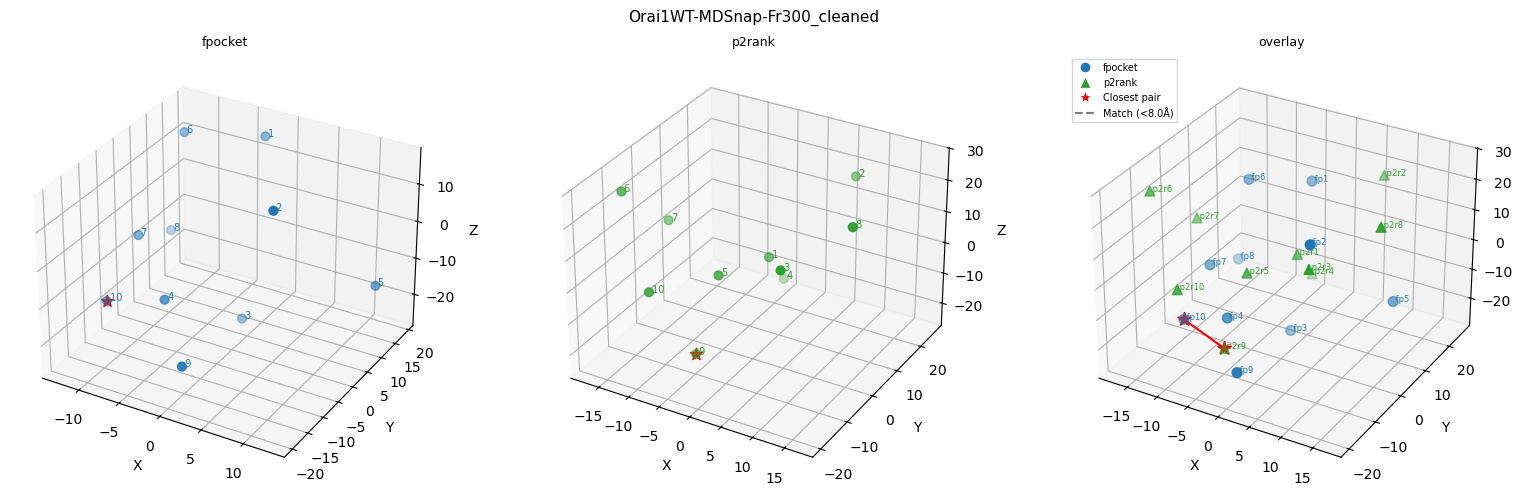


  Orai1WT-MDSnap-Fr400_cleaned — pairwise pocket distances (Å)


,p2r_6,p2r_7,p2r_3,p2r_9,p2r_2,p2r_1,p2r_5,p2r_4,p2r_10,p2r_8
fpocket \ p2rank,,,,,,,,,,
fp_3,3.9,56.4,54.5,28.8,38.4,29.2,41.9,30.4,21.2,52.2
fp_9,55.8,9.1,19.3,55.3,29.6,27.6,27.3,33.4,46.1,26.0
fp_1,47.0,13.3,10.3,42.1,30.0,18.4,16.2,27.8,42.1,25.9
fp_7,13.1,44.8,43.2,28.0,30.2,21.3,35.3,29.5,22.8,48.8
fp_4,33.9,42.5,32.5,13.5,44.5,21.7,17.5,26.3,40.9,36.2
fp_2,34.5,31.1,37.3,46.5,13.8,17.0,30.5,16.9,19.7,29.2
fp_6,42.7,15.3,18.4,42.8,22.9,14.1,18.4,22.5,35.2,24.0
fp_5,22.1,36.4,34.5,28.9,26.9,16.2,29.6,28.3,26.8,44.4
fp_8,28.7,44.0,37.1,17.4,40.5,18.6,19.0,17.8,33.4,32.2


  Closest pair: fpocket rank 3 ↔ p2rank rank 6, distance 3.94 Å, RMSD 2.27 Å


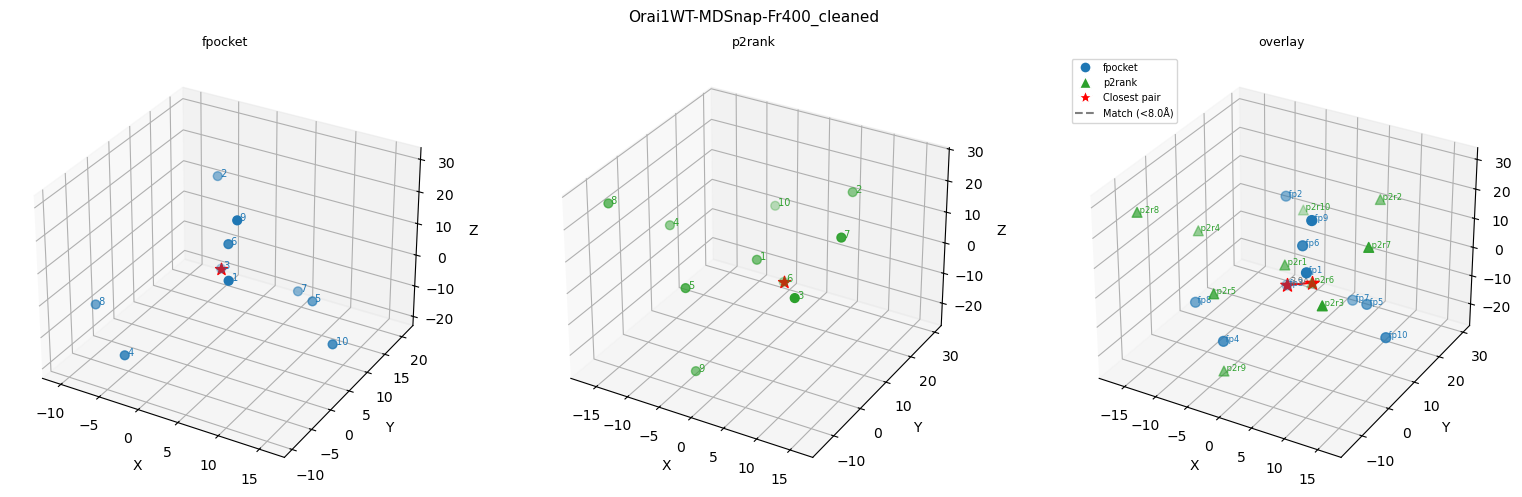


  Orai1WT-MDSnap-Fr499_cleaned — pairwise pocket distances (Å)


,p2r_1,p2r_7,p2r_8,p2r_4,p2r_5,p2r_3,p2r_2,p2r_10,p2r_6,p2r_9
fpocket \ p2rank,,,,,,,,,,
fp_1,8.9,25.5,38.0,13.7,34.2,23.9,18.7,25.8,25.8,29.0
fp_9,25.8,8.9,55.0,32.9,56.6,15.5,30.3,46.4,26.2,33.5
fp_8,33.9,55.6,9.8,41.4,35.5,44.3,55.6,51.3,51.6,33.9
fp_5,10.7,36.5,24.1,16.7,22.6,30.6,27.6,25.4,34.2,28.6
fp_6,12.6,16.2,42.6,21.7,43.2,14.7,23.4,35.5,23.9,26.9
fp_4,27.2,53.5,12.8,27.6,31.2,42.7,50.1,42.3,38.1,25.1
fp_7,14.4,24.8,33.7,28.3,36.0,20.2,27.2,36.0,37.6,30.9
fp_10,24.6,45.5,27.5,28.8,14.6,41.8,29.8,23.9,48.8,42.7
fp_3,17.9,45.6,17.6,17.3,23.3,37.2,38.2,30.7,33.6,25.7


  Closest pair: fpocket rank 1 ↔ p2rank rank 1, distance 8.95 Å, RMSD 5.17 Å


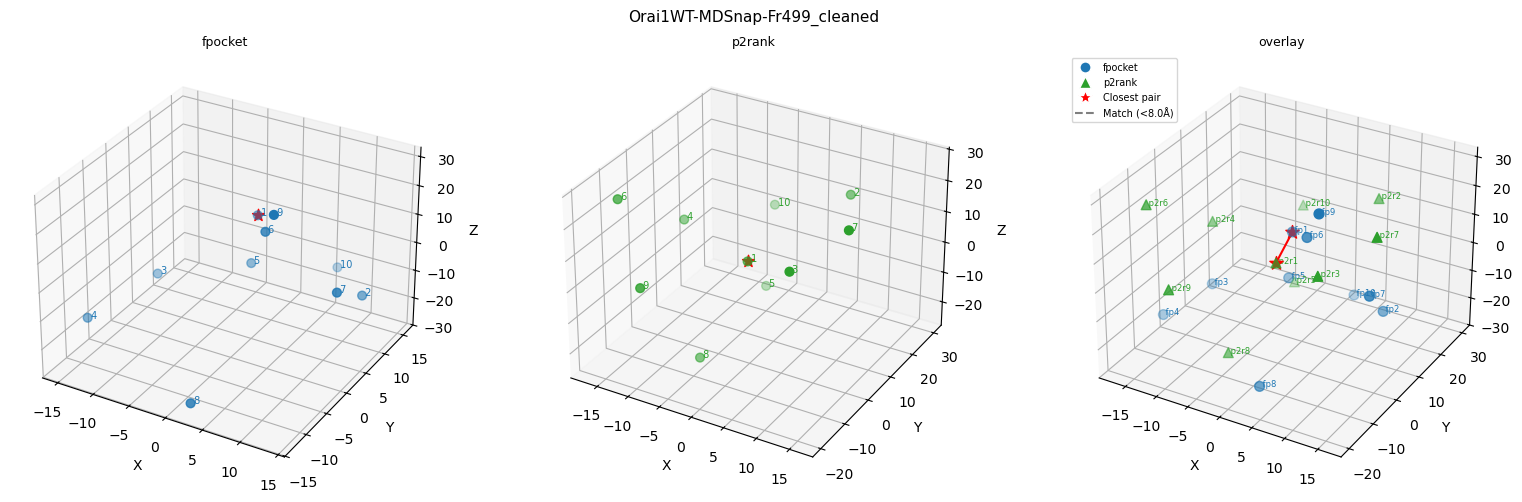


  Orai1WT-START-Fr0_cleaned — pairwise pocket distances (Å)


,p2r_5,p2r_10,p2r_1,p2r_7,p2r_8,p2r_9,p2r_6,p2r_4,p2r_3,p2r_2
fpocket \ p2rank,,,,,,,,,,
fp_1,1.9,27.3,24.1,15.6,17.9,18.0,18.2,26.7,27.3,24.7
fp_10,17.3,13.6,17.9,18.4,25.8,30.4,23.0,20.3,38.6,24.4
fp_7,23.2,37.1,14.2,37.6,22.6,42.3,35.6,27.8,22.7,40.4
fp_5,23.5,15.4,14.2,26.5,30.3,37.7,30.4,22.6,40.5,28.1
fp_3,20.2,29.1,15.6,31.0,33.5,29.8,37.9,39.5,26.0,21.0
fp_6,37.2,43.4,18.3,50.1,37.7,55.3,49.6,38.4,32.9,48.0
fp_4,26.0,44.8,23.9,41.3,19.4,44.9,36.0,29.2,20.4,47.4
fp_2,38.7,26.4,19.7,42.7,43.7,53.2,46.3,34.1,49.4,39.3
fp_8,42.6,30.1,22.0,47.4,51.0,54.6,53.8,45.0,50.4,37.0


  Closest pair: fpocket rank 1 ↔ p2rank rank 5, distance 1.94 Å, RMSD 1.12 Å


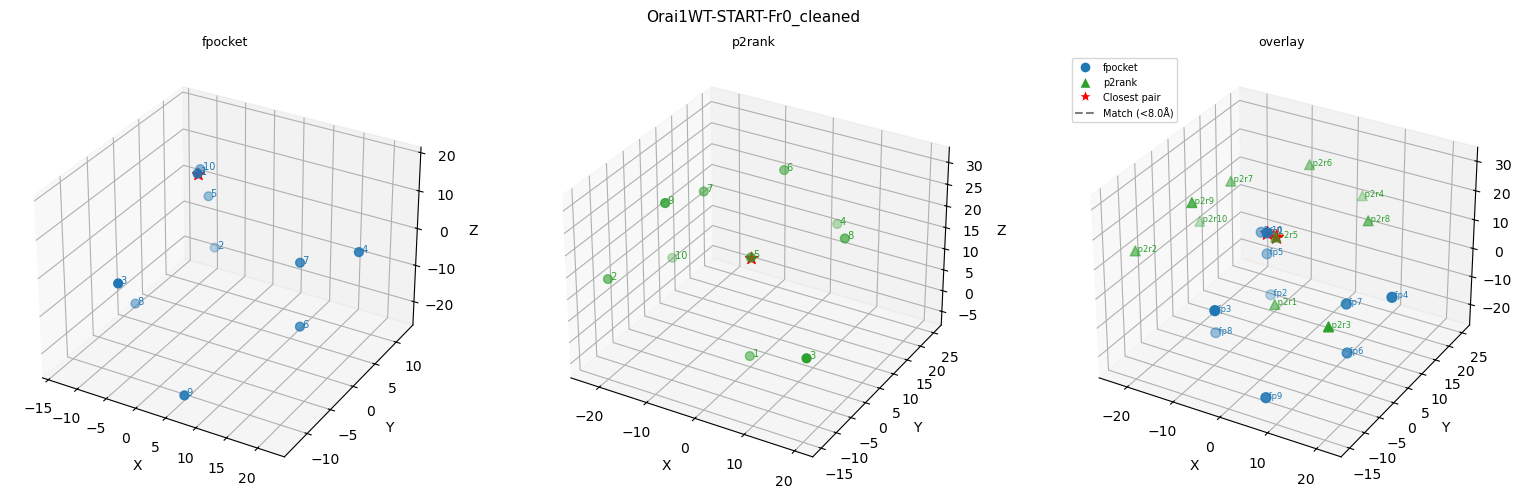

In [28]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

def rmsd(a, b):
    diff = a - b
    return np.sqrt(np.mean(diff ** 2))

for pdb_name in sorted(set(fpocket_results.keys()) & set(p2rank_results.keys())):
    fp_df = fpocket_results[pdb_name].dropna(subset=["center_x", "center_y", "center_z"])
    p2_df = p2rank_results[pdb_name].dropna(subset=["center_x", "center_y", "center_z"])
    if fp_df.empty or p2_df.empty:
        print(f"  {pdb_name}: insufficient coordinates for plotting")
        continue

    fp_coords = fp_df[["center_x", "center_y", "center_z"]].values
    p2_coords = p2_df[["center_x", "center_y", "center_z"]].values
    dist = cdist(fp_coords, p2_coords)

    # ── Distance matrix table ──
    fp_labels = [f"fp_{int(r['rank'])}" for _, r in fp_df.iterrows()]
    p2_labels = [f"p2r_{int(r['rank'])}" for _, r in p2_df.iterrows()]

    dist_df = pd.DataFrame(dist, index=fp_labels, columns=p2_labels)
    dist_df.index.name = "fpocket \\ p2rank"

    row_order = dist_df.min(axis=1).sort_values().index
    col_order = dist_df.min(axis=0).sort_values().index
    dist_df = dist_df.loc[row_order, col_order]

    print(f"\n  {pdb_name} — pairwise pocket distances (Å)")
    display(dist_df.style
            .format("{:.1f}")
            .background_gradient(cmap="RdYlGn_r", axis=None)
            .set_caption(f"{pdb_name}: fpocket vs p2rank distances (Å)"))

    # ── Closest-pocket summary ──
    i, j = np.unravel_index(dist.argmin(), dist.shape)
    closest_fp = fp_df.iloc[i]
    closest_p2 = p2_df.iloc[j]
    closest_rmsd = rmsd(fp_coords[i], p2_coords[j])

    print(f"  Closest pair: fpocket rank {int(closest_fp['rank'])} ↔ "
          f"p2rank rank {int(closest_p2['rank'])}, "
          f"distance {dist[i, j]:.2f} Å, RMSD {closest_rmsd:.2f} Å")

    # ── 3-panel plot ──
    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(f"{pdb_name}", fontsize=11)

    ax1 = fig.add_subplot(1, 3, 1, projection="3d")
    ax1.scatter(fp_coords[:, 0], fp_coords[:, 1], fp_coords[:, 2],
                c="tab:blue", s=40, depthshade=True)
    for k, (_, r) in enumerate(fp_df.iterrows()):
        ax1.text(fp_coords[k, 0], fp_coords[k, 1], fp_coords[k, 2],
                 f" {int(r['rank'])}", fontsize=7, color="tab:blue")
    ax1.scatter(*fp_coords[i], c="red", s=80, marker="*", zorder=5)
    ax1.set_title("fpocket", fontsize=9)
    ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")

    ax2 = fig.add_subplot(1, 3, 2, projection="3d")
    ax2.scatter(p2_coords[:, 0], p2_coords[:, 1], p2_coords[:, 2],
                c="tab:green", s=40, depthshade=True)
    for k, (_, r) in enumerate(p2_df.iterrows()):
        ax2.text(p2_coords[k, 0], p2_coords[k, 1], p2_coords[k, 2],
                 f" {int(r['rank'])}", fontsize=7, color="tab:green")
    ax2.scatter(*p2_coords[j], c="red", s=80, marker="*", zorder=5)
    ax2.set_title("p2rank", fontsize=9)
    ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_zlabel("Z")

    ax3 = fig.add_subplot(1, 3, 3, projection="3d")
    ax3.scatter(fp_coords[:, 0], fp_coords[:, 1], fp_coords[:, 2],
                c="tab:blue", s=50, marker="o", depthshade=True, label="fpocket")
    for k, (_, r) in enumerate(fp_df.iterrows()):
        ax3.text(fp_coords[k, 0], fp_coords[k, 1], fp_coords[k, 2],
                 f" fp{int(r['rank'])}", fontsize=6, color="tab:blue")
    ax3.scatter(p2_coords[:, 0], p2_coords[:, 1], p2_coords[:, 2],
                c="tab:green", s=50, marker="^", depthshade=True, label="p2rank")
    for k, (_, r) in enumerate(p2_df.iterrows()):
        ax3.text(p2_coords[k, 0], p2_coords[k, 1], p2_coords[k, 2],
                 f" p2r{int(r['rank'])}", fontsize=6, color="tab:green")

    for fi in range(len(fp_coords)):
        nearest_j = dist[fi].argmin()
        d = dist[fi, nearest_j]
        if d < DISTANCE_THRESHOLD:
            ax3.plot(
                [fp_coords[fi, 0], p2_coords[nearest_j, 0]],
                [fp_coords[fi, 1], p2_coords[nearest_j, 1]],
                [fp_coords[fi, 2], p2_coords[nearest_j, 2]],
                'k--', lw=0.8, alpha=0.5,
            )
            mid = (fp_coords[fi] + p2_coords[nearest_j]) / 2
            ax3.text(mid[0], mid[1], mid[2], f"{d:.1f}Å", fontsize=6,
                     color="dimgray", ha="center")

    ax3.scatter(*fp_coords[i], c="red", s=100, marker="*", zorder=5)
    ax3.scatter(*p2_coords[j], c="red", s=100, marker="*", zorder=5)
    ax3.plot(
        [fp_coords[i, 0], p2_coords[j, 0]],
        [fp_coords[i, 1], p2_coords[j, 1]],
        [fp_coords[i, 2], p2_coords[j, 2]],
        'r-', lw=1.5,
    )

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=8, label='fpocket'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='tab:green', markersize=8, label='p2rank'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=10, label='Closest pair'),
        Line2D([0], [0], linestyle='--', color='k', alpha=0.5, label=f'Match (<{DISTANCE_THRESHOLD}Å)'),
    ]
    ax3.legend(handles=legend_elements, fontsize=7, loc="upper left")
    ax3.set_title("overlay", fontsize=9)
    ax3.set_xlabel("X"); ax3.set_ylabel("Y"); ax3.set_zlabel("Z")

    plt.tight_layout()
    plt.show()
